# Zeit- und Frequenzbereich (Piano)

Analyse eines Piano-Audiosignals (D4) im Zeit- und Frequenzbereich.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hoeverc/laermarmesysteme_medien/blob/main/Python/VL1/ZeitUndFrequenzbereich_Piano.ipynb)

In [1]:
import os
import ssl
import urllib.request

GITHUB_RAW=(
  'https://raw.githubusercontent.com'
  '/hoeverc/laermarmesysteme_medien/main')

def download(url, path):
  """Download file if not already present."""
  os.makedirs(
    os.path.dirname(path) or '.', exist_ok=True)
  if os.path.exists(path):
    with open(path, 'rb') as f:
      head=f.read(4)
    if head not in (b'RIFF', b'RIFX', b'RF64'):
      os.remove(path)
  if not os.path.exists(path):
    urllib.request.urlretrieve(url, path)
  with open(path, 'rb') as f:
    head=f.read(4)
  if head==b'vers':
    os.remove(path)
    media_url=url.replace(
      'https://raw.githubusercontent.com',
      'https://media.githubusercontent.com/media')
    ctx=ssl._create_unverified_context()
    with urllib.request.urlopen(media_url, context=ctx) as r:
      with open(path, 'wb') as out:
        out.write(r.read())
  print(f'Heruntergeladen: {path}')

download(
  f'{GITHUB_RAW}/VL1/Medien/'
  '176516__goup-1__piano-key-d4.wav',
  'Medien/176516__goup-1__piano-key-d4.wav')

Heruntergeladen: Medien/176516__goup-1__piano-key-d4.wav


C:\Users\hoeverc\AppData\Local\Temp\ipykernel_10428\4056870880.py:13: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data=wavfile.read(


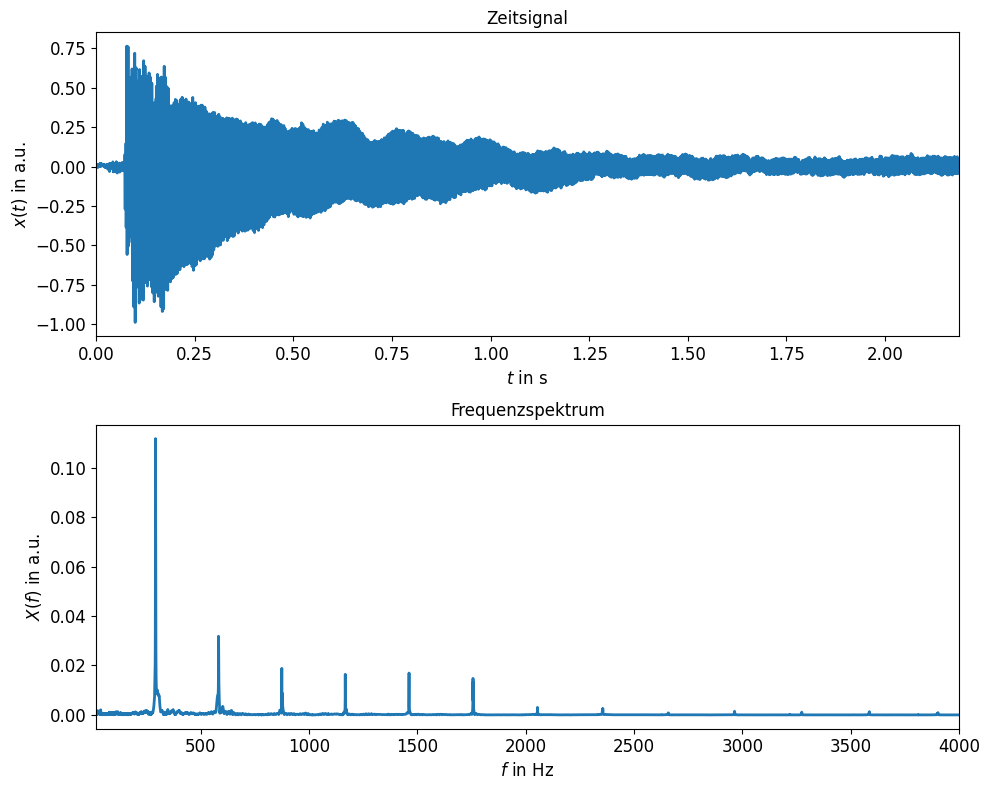

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

# ===========================================================
# Audio einlesen
# ===========================================================
fontsize=12
linewidth=2
freqlims=[16, 4000]

sr, data=wavfile.read(
  'Medien/176516__goup-1__piano-key-d4.wav')
if data.ndim>1:
  data=data[:, 0]
if np.issubdtype(data.dtype, np.integer):
  x=data.astype(np.float64)/np.iinfo(data.dtype).max
else:
  x=data.astype(np.float64)

# Erstes 1/6 des Signals verwenden
x=x[:len(x)//6]
fs=sr

# ===========================================================
# FFT: einseitiges Amplitudenspektrum
# ===========================================================
n=len(x)
T=n/fs
t=np.arange(n)/fs
fmax=fs/2
f=np.linspace(0, fmax, n//2+1)

X_full=np.fft.fft(x)/n
X=2*X_full[:n//2+1].copy()
X[0]/=2
X[-1]/=2

# ===========================================================
# Plot
# ===========================================================
fig, (ax1, ax2)=plt.subplots(
  2, 1, figsize=(10, 8))

ax1.plot(t, x, linewidth=linewidth)
ax1.set_xlabel(r'$t$ in s', fontsize=fontsize)
ax1.set_ylabel(
  r'$x(t)$ in a.u.', fontsize=fontsize)
ax1.set_xlim(0, T)
ax1.set_title('Zeitsignal')
ax1.tick_params(labelsize=fontsize)

ax2.plot(f, np.abs(X), linewidth=linewidth)
ax2.set_xlabel(r'$f$ in Hz', fontsize=fontsize)
ax2.set_ylabel(
  r'$X(f)$ in a.u.', fontsize=fontsize)
ax2.set_xlim(*freqlims)
ax2.set_title('Frequenzspektrum')
ax2.tick_params(labelsize=fontsize)

plt.tight_layout()
plt.show()

# Audio abspielen
display(Audio(data=x, rate=fs))